In [1]:
# Importar librerias 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")


In [2]:
# Crear DF

np.random.seed(42)

fechas = pd.date_range(
    start="2015-01-01",
    periods=120,
    freq="MS"
)

tendencia = np.linspace(200, 500, 120)

estacionalidad = 50 * np.sin(2 * np.pi * np.arange(120) / 12)

ruido = np.random.normal(0, 15, 120)

ventas = tendencia + estacionalidad + ruido

df = pd.DataFrame({
    "Fecha": fechas,
    "Ventas": ventas
})

df.head()

,Fecha,Ventas
0,2015-01-01,207.450712
1,2015-02-01,225.447044
2,2015-03-01,258.058615
3,2015-04-01,280.408473
4,2015-05-01,249.873003


In [3]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
df.set_index("Fecha", inplace=True)
df.head()

,Ventas
Fecha,
2015-01-01,207.450712
2015-02-01,225.447044
2015-03-01,258.058615
2015-04-01,280.408473
2015-05-01,249.873003


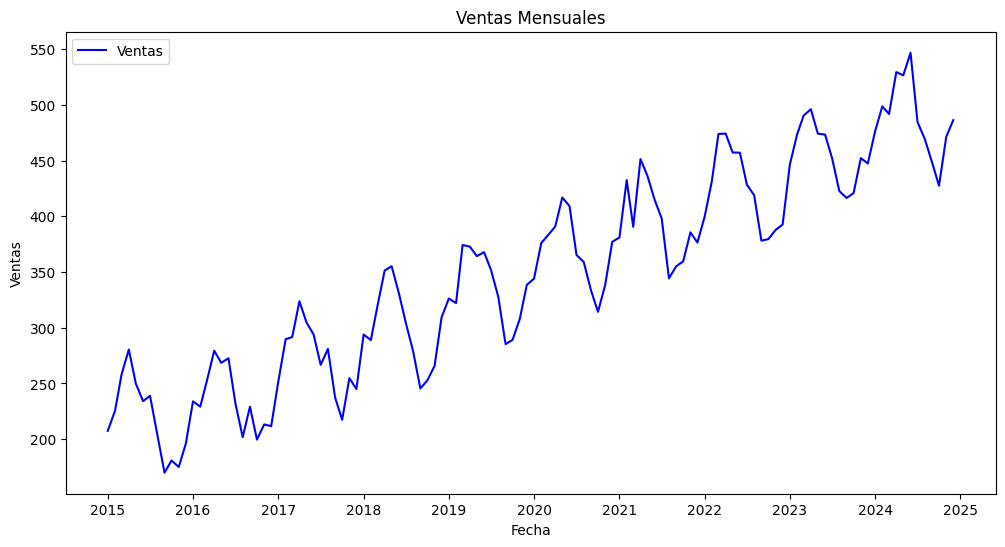

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Ventas"], label="Ventas", color="blue")
plt.title("Ventas Mensuales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()

In [5]:
train = df[:-12]
test = df[-12:]

print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (108, 1), Test shape: (12, 1)


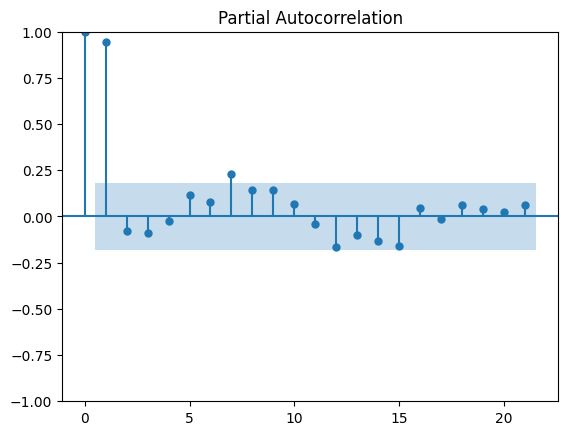

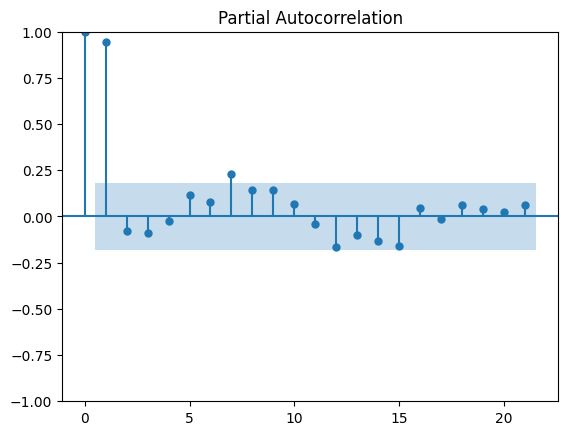

In [6]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df["Ventas"])

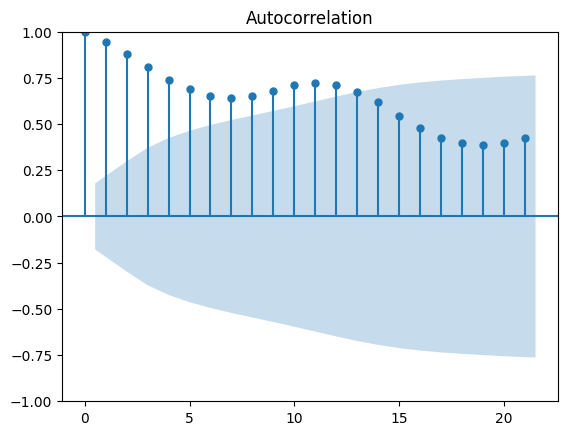

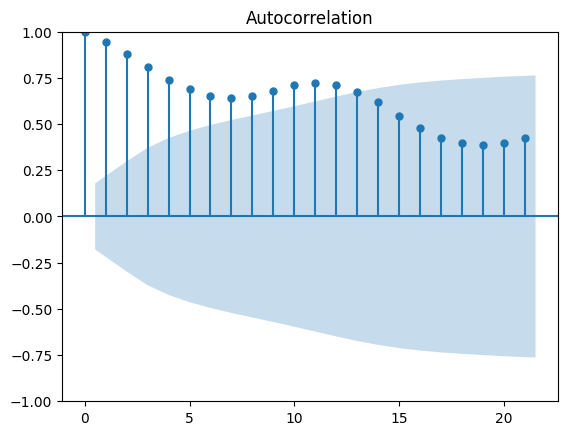

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["Ventas"])

In [8]:
# SARIMA

# Definir el modelo SARIMA
sarima_model = SARIMAX(train["Ventas"], order=(2, 1, 2), seasonal_order=(1, 1, 1, 12)) # order: p, d, q; seasonal_order: P, D, Q, s

# Results

sarima_result = sarima_model.fit()

print(sarima_result.summary())


                                      SARIMAX Results                                       
Dep. Variable:                               Ventas   No. Observations:                  108
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                -398.693
Date:                              Wed, 29 Jul 2026   AIC                            811.385
Time:                                      10:22:17   BIC                            829.263
Sample:                                  01-01-2015   HQIC                           818.609
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8478      0.285     -2.978      0.003      -1.406      -0.290
ar.L2         -0.05

MAE: 9.612337166279877
2024-01-01    470.566911
2024-02-01    493.780847
2024-03-01    509.614389
2024-04-01    533.287908
2024-05-01    522.337975
2024-06-01    514.921059
2024-07-01    489.463614
2024-08-01    468.822420
2024-09-01    446.306816
2024-10-01    442.209452
2024-11-01    459.493508
2024-12-01    473.634475
Freq: MS, Name: predicted_mean, dtype: float64


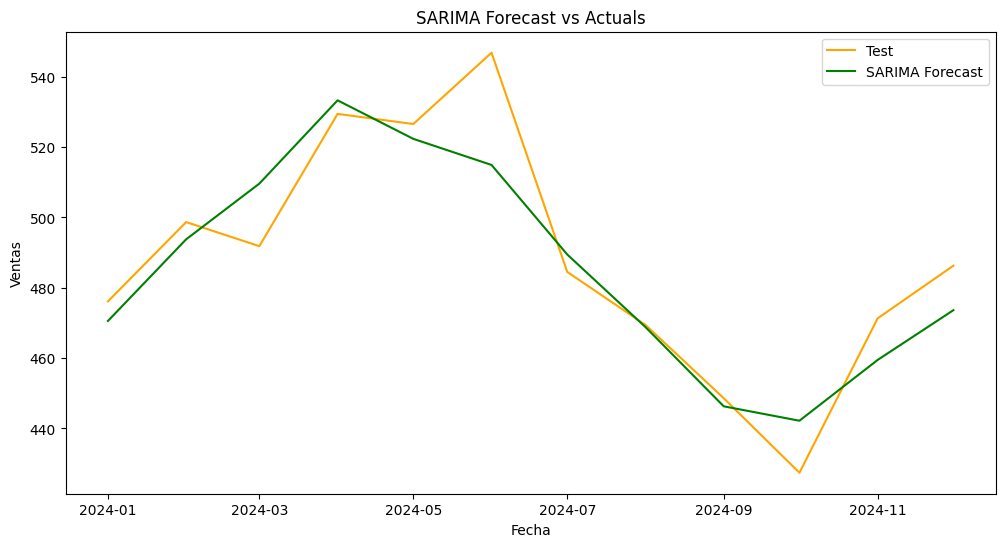

In [11]:
sarima_forecast = sarima_result.forecast(steps=12)
plt.figure(figsize=(12, 6))
plt.plot(test.index, test["Ventas"], label="Test", color="orange")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast", color="green")
plt.title("SARIMA Forecast vs Actuals")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()

print(f"MAE: {mean_absolute_error(test['Ventas'], sarima_forecast)}")
print(sarima_forecast)